# 第 10 章 · ViT Patchify 代码实验

[章节网页](../ch10.html)

## 运行内容

- 切分 patch token
- 查看 token 表
- 绘制 patch

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 把 8x8 图像切成 2x2 patch token。
vit_image = np.arange(64).reshape(8, 8)
patch_size = 2
patches = vit_image.reshape(4, patch_size, 4, patch_size).swapaxes(1, 2)
patch_tokens = patches.reshape(-1, patch_size * patch_size)

patch_df = pd.DataFrame(patch_tokens, columns=["p00", "p01", "p10", "p11"])
patch_df.insert(0, "patch_id", range(len(patch_df)))
display(patch_df.head(8))

,patch_id,p00,p01,p10,p11
0,0,0,1,8,9
1,1,2,3,10,11
2,2,4,5,12,13
3,3,6,7,14,15
4,4,16,17,24,25
5,5,18,19,26,27
6,6,20,21,28,29
7,7,22,23,30,31


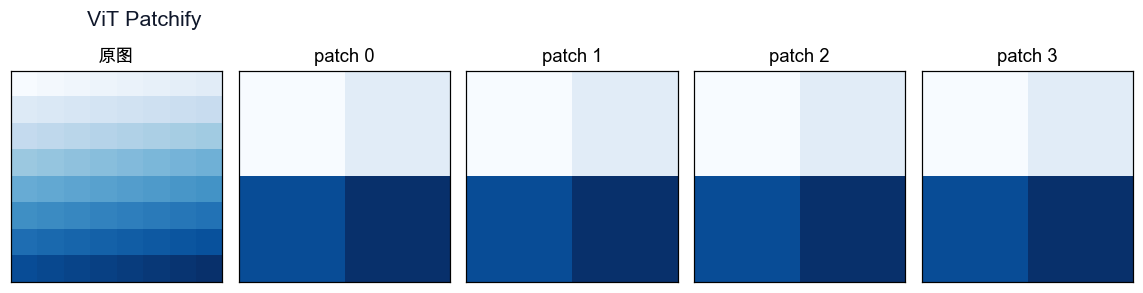

In [3]:
# 绘制原图和前几个 patch。
fig, axes = plt.subplots(1, 5, figsize=(10.5, 2.8))
axes[0].imshow(vit_image, cmap="Blues")
axes[0].set_title("原图", fontweight="bold")
axes[0].set_xticks([])
axes[0].set_yticks([])
for idx in range(4):
    axes[idx + 1].imshow(patch_tokens[idx].reshape(2, 2), cmap="Blues")
    axes[idx + 1].set_title(f"patch {idx}", fontweight="bold")
    axes[idx + 1].set_xticks([])
    axes[idx + 1].set_yticks([])
fig.suptitle("ViT Patchify", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()